Sales Summary Table:
    product  total_quantity  total_revenue
0    Eraser              50           50.0
1  Notebook              15          300.0
2       Pen              30          150.0
3    Pencil              30           60.0


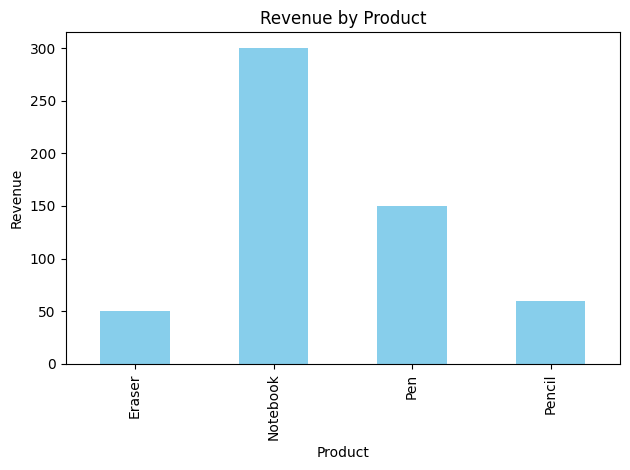

In [1]:
# Importing required modules
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create in-memory SQLite database
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

# Step 2: Create 'sales' table
cursor.execute('''
CREATE TABLE sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

# Step 3: Insert sample sales data
sales_data = [
    ("Pen", 10, 5.0),
    ("Notebook", 5, 20.0),
    ("Pen", 20, 5.0),
    ("Pencil", 30, 2.0),
    ("Notebook", 10, 20.0),
    ("Eraser", 50, 1.0)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sales_data)
conn.commit()

# Step 4: Run SQL query to summarize sales
query = '''
SELECT
    product,
    SUM(quantity) AS total_quantity,
    SUM(quantity * price) AS total_revenue
FROM
    sales
GROUP BY
    product
'''
df = pd.read_sql_query(query, conn)

# Step 5: Display DataFrame
print("Sales Summary Table:")
print(df)

# Step 6: Plot bar chart of total revenue
df.plot(kind='bar', x='product', y='total_revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Close the database connection
conn.close()
